# DDS 8555: Predictive Analytics
## Applied Question 9 — Hierarchical Clustering of the `USArrests` Data

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 20, 2026

**Text:** *An Introduction to Statistical Learning: With Applications in Python*  
**Exercise:** Chapter 12, Applied Question 9, p. 554

### Purpose

This notebook performs complete-linkage hierarchical clustering of the 50 U.S. states using Euclidean distance.  It answers all four parts of the exercise by comparing results from the original variables with results after each variable is standardized to sample standard deviation one.

The four variables are `Murder`, `Assault`, and `Rape` arrests per 100,000 residents, plus `UrbanPop`, the percentage of the population living in urban areas (R Core Team, n.d.).  The data describe 1973 observations.  The values are embedded below so that the analysis is fully reproducible without network access.


## Question

**(a)** Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states.  
**(b)** Cut the dendrogram at a height that results in three distinct clusters.  Which states belong to which clusters?  
**(c)** Repeat the clustering after scaling the variables to have standard deviation one.  
**(d)** Explain the effect of scaling and whether scaling should be performed before computing inter-observation dissimilarities.

### Analytical method

For observations $x_i$ and $x_{i'}$, Euclidean distance is

$$
d(i,i')=\sqrt{\sum_{j=1}^{p}(x_{ij}-x_{i'j})^2}.
$$

For two clusters $A$ and $B$, complete linkage defines their dissimilarity as

$$
d_{\mathrm{complete}}(A,B)=\max_{i\in A,\;i'\in B}d(i,i').
$$

At each step, the pair of active clusters with the smallest complete-linkage dissimilarity is merged.  For part (c), each column is transformed using its sample mean and sample standard deviation:

$$
z_{ij}=\frac{x_{ij}-\bar{x}_j}{s_j},
\qquad
s_j=\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_{ij}-\bar{x}_j)^2}.
$$


## 1. Setup and reproducibility

Only NumPy is required for the analysis. The dendrograms are generated directly as SVG, so the notebook does not depend on Matplotlib. The embedded data, deterministic tie-breaking, and documented calculations make the analysis fully reproducible.


<style>
div.input_area pre {
    white-space: pre-wrap !important;
    overflow-wrap: anywhere !important;
    word-break: normal !important;
}

.jp-InputArea pre,
.jp-CodeCell .cm-line {
    white-space: pre-wrap !important;
    overflow-wrap: anywhere !important;
    word-break: normal !important;
}
</style>

In [1]:
import html
import itertools
from textwrap import wrap

import numpy as np

np.set_printoptions(precision=3, suppress=True)

print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


## 2. Data

The state names and all four measurements are embedded exactly once in this notebook. No external file, web request, or unrelated data set is used.


In [2]:
feature_names = np.array(["Murder", "Assault", "UrbanPop", "Rape"])

rows = [
    ("Alabama", 13.2, 236, 58, 21.2),
    ("Alaska", 10.0, 263, 48, 44.5),
    ("Arizona", 8.1, 294, 80, 31.0),
    ("Arkansas", 8.8, 190, 50, 19.5),
    ("California", 9.0, 276, 91, 40.6),
    ("Colorado", 7.9, 204, 78, 38.7),
    ("Connecticut", 3.3, 110, 77, 11.1),
    ("Delaware", 5.9, 238, 72, 15.8),
    ("Florida", 15.4, 335, 80, 31.9),
    ("Georgia", 17.4, 211, 60, 25.8),
    ("Hawaii", 5.3, 46, 83, 20.2),
    ("Idaho", 2.6, 120, 54, 14.2),
    ("Illinois", 10.4, 249, 83, 24.0),
    ("Indiana", 7.2, 113, 65, 21.0),
    ("Iowa", 2.2, 56, 57, 11.3),
    ("Kansas", 6.0, 115, 66, 18.0),
    ("Kentucky", 9.7, 109, 52, 16.3),
    ("Louisiana", 15.4, 249, 66, 22.2),
    ("Maine", 2.1, 83, 51, 7.8),
    ("Maryland", 11.3, 300, 67, 27.8),
    ("Massachusetts", 4.4, 149, 85, 16.3),
    ("Michigan", 12.1, 255, 74, 35.1),
    ("Minnesota", 2.7, 72, 66, 14.9),
    ("Mississippi", 16.1, 259, 44, 17.1),
    ("Missouri", 9.0, 178, 70, 28.2),
    ("Montana", 6.0, 109, 53, 16.4),
    ("Nebraska", 4.3, 102, 62, 16.5),
    ("Nevada", 12.2, 252, 81, 46.0),
    ("New Hampshire", 2.1, 57, 56, 9.5),
    ("New Jersey", 7.4, 159, 89, 18.8),
    ("New Mexico", 11.4, 285, 70, 32.1),
    ("New York", 11.1, 254, 86, 26.1),
    ("North Carolina", 13.0, 337, 45, 16.1),
    ("North Dakota", 0.8, 45, 44, 7.3),
    ("Ohio", 7.3, 120, 75, 21.4),
    ("Oklahoma", 6.6, 151, 68, 20.0),
    ("Oregon", 4.9, 159, 67, 29.3),
    ("Pennsylvania", 6.3, 106, 72, 14.9),
    ("Rhode Island", 3.4, 174, 87, 8.3),
    ("South Carolina", 14.4, 279, 48, 22.5),
    ("South Dakota", 3.8, 86, 45, 12.8),
    ("Tennessee", 13.2, 188, 59, 26.9),
    ("Texas", 12.7, 201, 80, 25.5),
    ("Utah", 3.2, 120, 80, 22.9),
    ("Vermont", 2.2, 48, 32, 11.2),
    ("Virginia", 8.5, 156, 63, 20.7),
    ("Washington", 4.0, 145, 73, 26.2),
    ("West Virginia", 5.7, 81, 39, 9.3),
    ("Wisconsin", 2.6, 53, 66, 10.8),
    ("Wyoming", 6.8, 161, 60, 15.6),
]

states = np.array([row[0] for row in rows])
X = np.array([row[1:] for row in rows], dtype=float)

print(f"Observations: {X.shape[0]}")
print(f"Variables:    {X.shape[1]}")
print("\nFirst six rows:")
print(f"{'State':<15}" + "".join(f"{name:>11}" for name in feature_names))
for state, values in zip(states[:6], X[:6]):
    print(f"{state:<15}" + "".join(f"{value:>11.1f}" for value in values))


Observations: 50
Variables:    4

First six rows:
State               Murder    Assault   UrbanPop       Rape
Alabama               13.2      236.0       58.0       21.2
Alaska                10.0      263.0       48.0       44.5
Arizona                8.1      294.0       80.0       31.0
Arkansas               8.8      190.0       50.0       19.5
California             9.0      276.0       91.0       40.6
Colorado               7.9      204.0       78.0       38.7


In [3]:
means = X.mean(axis=0)
sample_sds = X.std(axis=0, ddof=1)

print(f"{'Variable':<12}{'Mean':>10}{'Sample SD':>12}{'Minimum':>12}{'Maximum':>12}")
for j, name in enumerate(feature_names):
    print(
        f"{name:<12}{means[j]:>10.3f}{sample_sds[j]:>12.3f}"
        f"{X[:, j].min():>12.1f}{X[:, j].max():>12.1f}"
    )


Variable          Mean   Sample SD     Minimum     Maximum
Murder           7.788       4.356         0.8        17.4
Assault        170.760      83.338        45.0       337.0
UrbanPop        65.540      14.475        32.0        91.0
Rape            21.232       9.366         7.3        46.0


The unscaled standard deviations are very different.  In particular, the standard deviation of `Assault` is much larger numerically than those of the other variables.  Consequently, squared differences in `Assault` can dominate Euclidean distance unless the variables are standardized.


## 3. Complete-linkage clustering functions

The process starts by treating each state as its own group.  It then compares the groups and combines the two that are most alike.  With complete linkage, the distance between two groups is based on the pair of states—one from each group—that are farthest apart.  The process continues step by step until every state is connected within a single hierarchy.  The cluster numbers shown later simply distinguish one group from another; they do not indicate rank, quality, or importance.


In [4]:
def pairwise_euclidean(data):
    """Return the full Euclidean distance matrix."""
    differences = data[:, None, :] - data[None, :, :]
    return np.sqrt(np.sum(differences ** 2, axis=2))


def complete_linkage(data):
    """Agglomerative hierarchical clustering with complete linkage."""
    n = data.shape[0]
    point_distances = pairwise_euclidean(data)
    members = {i: np.array([i], dtype=int) for i in range(n)}
    active = list(range(n))
    linkage = []

    for step in range(n - 1):
        best_key = None
        best_pair = None

        for position, left in enumerate(active[:-1]):
            for right in active[position + 1:]:
                distance = point_distances[np.ix_(members[left], members[right])].max()
                key = (float(distance), min(left, right), max(left, right))
                if best_key is None or key < best_key:
                    best_key = key
                    best_pair = (left, right)

        left, right = best_pair
        new_id = n + step
        new_members = np.concatenate((members[left], members[right]))
        linkage.append([left, right, best_key[0], new_members.size])
        members[new_id] = new_members
        active = [node for node in active if node not in (left, right)]
        active.append(new_id)

    return np.asarray(linkage, dtype=float)


def cut_into_k_clusters(linkage, n_observations, k=3):
    """Cut a linkage tree into exactly k clusters."""
    active = {i: {i} for i in range(n_observations)}
    for step, row in enumerate(linkage[: n_observations - k]):
        left, right = int(row[0]), int(row[1])
        active[n_observations + step] = active.pop(left) | active.pop(right)

    ordered = sorted(active.values(), key=lambda group: min(group))
    labels = np.empty(n_observations, dtype=int)
    for label, group in enumerate(ordered, start=1):
        labels[list(group)] = label
    return labels, ordered


def three_cluster_cut_height(linkage, n_observations):
    """Choose a height midway between the last included and next merge."""
    lower = linkage[n_observations - 3 - 1, 2]
    upper = linkage[n_observations - 3, 2]
    return float((lower + upper) / 2)


def print_memberships(labels, state_names):
    for cluster in np.unique(labels):
        names = state_names[labels == cluster].tolist()

        print(f"Cluster {cluster} (n = {len(names)}):")

        membership_text = ", ".join(names)

        for line in wrap(
            membership_text,
            width=78,
            break_long_words=False,
            break_on_hyphens=False,
        ):
            print("    " + line)

        print()


In [5]:
def dendrogram_svg(linkage, labels, title, cut_height=None):
    """Create a dependency-free SVG dendrogram from a linkage matrix."""
    n = len(labels)
    children = {
        n + step: (int(row[0]), int(row[1]))
        for step, row in enumerate(linkage)
    }
    heights = {i: 0.0 for i in range(n)}
    heights.update({n + step: float(row[2]) for step, row in enumerate(linkage)})

    def leaf_order(node):
        if node < n:
            return [node]
        left, right = children[node]
        return leaf_order(left) + leaf_order(right)

    root = 2 * n - 2
    order = leaf_order(root)
    width, height = 1500, 760
    left_margin, right_margin = 70, 25
    top_margin, baseline = 65, 560
    plot_width = width - left_margin - right_margin
    plot_height = baseline - top_margin
    max_height = float(linkage[:, 2].max()) * 1.04

    x = {
        leaf: left_margin + rank * plot_width / (n - 1)
        for rank, leaf in enumerate(order)
    }

    def y(value):
        return baseline - (value / max_height) * plot_height

    elements = [
        f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}" width="100%">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<text x="{width / 2}" y="28" text-anchor="middle" font-family="Arial" font-size="21" font-weight="bold">{html.escape(title)}</text>',
        f'<line x1="{left_margin}" y1="{baseline}" x2="{width-right_margin}" y2="{baseline}" stroke="#555" stroke-width="1"/>',
    ]

    for step, row in enumerate(linkage):
        node = n + step
        left, right = children[node]
        x_left, x_right = x[left], x[right]
        y_left, y_right, y_node = y(heights[left]), y(heights[right]), y(heights[node])
        elements.extend([
            f'<line x1="{x_left:.2f}" y1="{y_left:.2f}" x2="{x_left:.2f}" y2="{y_node:.2f}" stroke="#244a73" stroke-width="1.6"/>',
            f'<line x1="{x_right:.2f}" y1="{y_right:.2f}" x2="{x_right:.2f}" y2="{y_node:.2f}" stroke="#244a73" stroke-width="1.6"/>',
            f'<line x1="{x_left:.2f}" y1="{y_node:.2f}" x2="{x_right:.2f}" y2="{y_node:.2f}" stroke="#244a73" stroke-width="1.6"/>',
        ])
        x[node] = (x_left + x_right) / 2

    if cut_height is not None:
        cut_y = y(cut_height)
        elements.extend([
            f'<line x1="{left_margin}" y1="{cut_y:.2f}" x2="{width-right_margin}" y2="{cut_y:.2f}" stroke="#b22222" stroke-width="2" stroke-dasharray="9,7"/>',
            f'<text x="{width-right_margin-4}" y="{cut_y-7:.2f}" text-anchor="end" font-family="Arial" font-size="14" fill="#b22222">three-cluster cut: {cut_height:.3f}</text>',
        ])

    for leaf in order:
        x_leaf = x[leaf]
        label = html.escape(str(labels[leaf]))
        elements.append(
            f'<text transform="translate({x_leaf:.2f},{baseline+10}) rotate(-65)" '
            f'text-anchor="end" font-family="Arial" font-size="11">{label}</text>'
        )

    for tick in np.linspace(0, max_height, 6):
        tick_y = y(float(tick))
        elements.extend([
            f'<line x1="{left_margin-5}" y1="{tick_y:.2f}" x2="{left_margin}" y2="{tick_y:.2f}" stroke="#555"/>',
            f'<text x="{left_margin-9}" y="{tick_y+4:.2f}" text-anchor="end" font-family="Arial" font-size="12">{tick:.1f}</text>',
        ])

    elements.append(
        f'<text transform="translate(18,{(top_margin+baseline)/2}) rotate(-90)" text-anchor="middle" font-family="Arial" font-size="14">Complete-linkage height</text>'
    )
    elements.append('</svg>')
    return "".join(elements)


def display_svg(svg_text):
    """Display SVG in Jupyter; retain it for the notebook execution harness."""
    try:
        from IPython.display import SVG, display
        display(SVG(svg_text))
    except ImportError:
        print("SVG dendrogram generated. Open this notebook in Jupyter to display it.")
    globals()["_codex_svg_output"] = svg_text


## 4. Parts (a) and (b):  Clustering the unscaled data

The first analysis uses the measurements in their original units.  The dashed red line is placed between the 47th and 48th merge heights, so it intersects exactly three branches and therefore yields three clusters.


Final merge height:          293.623
Chosen three-cluster height: 135.736
Number of clusters:          3


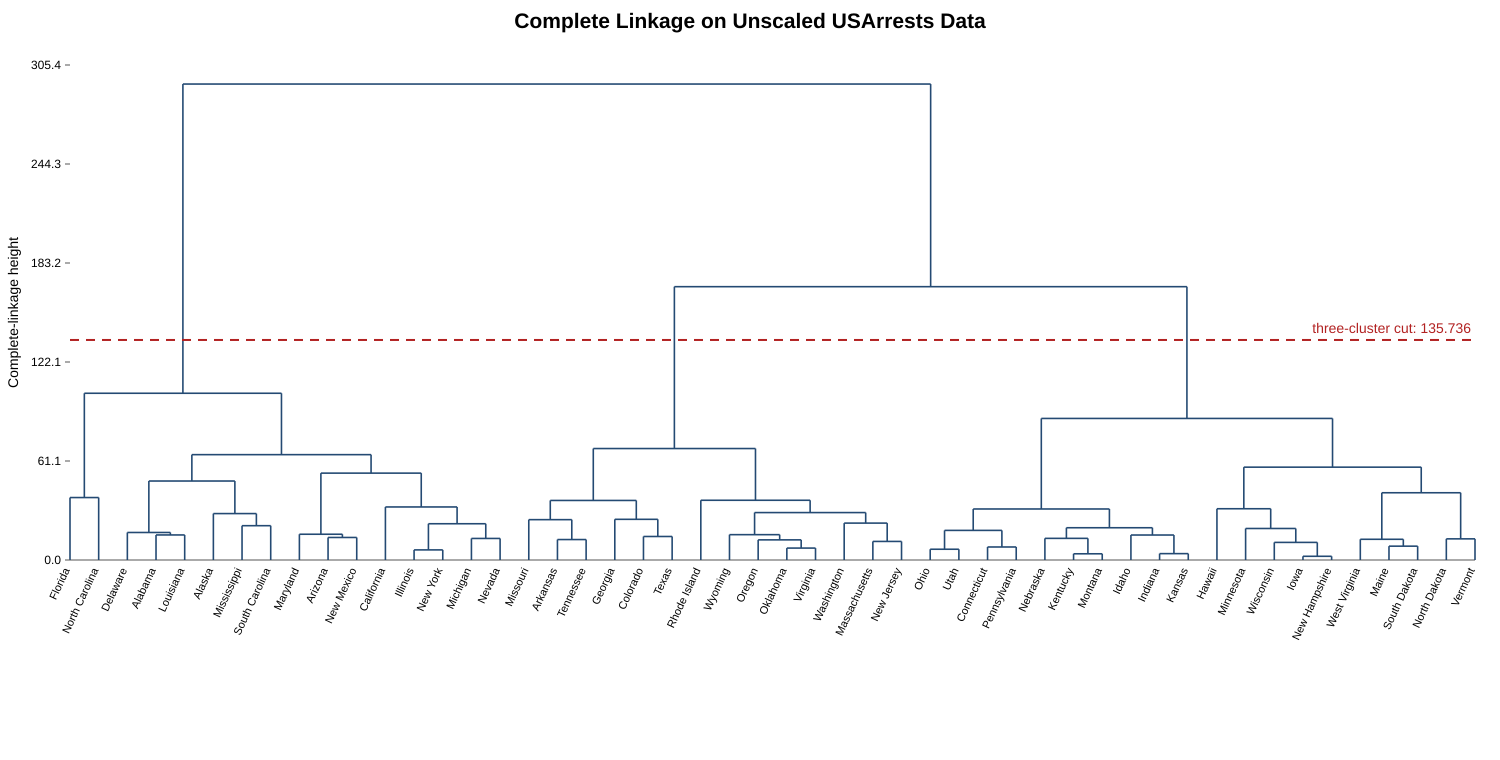

In [6]:
linkage_raw = complete_linkage(X)
labels_raw, groups_raw = cut_into_k_clusters(linkage_raw, len(states), k=3)
cut_raw = three_cluster_cut_height(linkage_raw, len(states))

print(f"Final merge height:          {linkage_raw[-1, 2]:.3f}")
print(f"Chosen three-cluster height: {cut_raw:.3f}")
print(f"Number of clusters:          {len(np.unique(labels_raw))}")

svg_raw = dendrogram_svg(
    linkage_raw,
    states,
    "Complete Linkage on Unscaled USArrests Data",
    cut_height=cut_raw,
)
display_svg(svg_raw)


### Answer to part (b): Three-cluster membership before scaling


In [7]:
print_memberships(labels_raw, states)


Cluster 1 (n = 16):
    Alabama, Alaska, Arizona, California, Delaware, Florida, Illinois, Louisiana,
    Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina,
    South Carolina

Cluster 2 (n = 14):
    Arkansas, Colorado, Georgia, Massachusetts, Missouri, New Jersey, Oklahoma,
    Oregon, Rhode Island, Tennessee, Texas, Virginia, Washington, Wyoming

Cluster 3 (n = 20):
    Connecticut, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Minnesota,
    Montana, Nebraska, New Hampshire, North Dakota, Ohio, Pennsylvania, South
    Dakota, Utah, Vermont, West Virginia, Wisconsin



In [8]:
print("Original-variable means within each unscaled-data cluster")
print(f"{'Cluster':<10}{'n':>4}" + "".join(f"{name:>12}" for name in feature_names))
for cluster in np.unique(labels_raw):
    mask = labels_raw == cluster
    cluster_means = X[mask].mean(axis=0)
    print(
        f"{cluster:<10}{mask.sum():>4}" +
        "".join(f"{value:>12.2f}" for value in cluster_means)
    )


Original-variable means within each unscaled-data cluster
Cluster      n      Murder     Assault    UrbanPop        Rape
1           16       11.81      272.56       68.31       28.38
2           14        8.21      173.29       70.64       22.84
3           20        4.27       87.55       59.75       14.39


**Interpretation.**  The unscaled clustering primarily separates states by the magnitude of their violent-crime arrest rates, especially `Assault`.  The strong influence of `Assault` is expected because the variable has by far the largest numerical spread and therefore contributes most heavily to the unscaled Euclidean distances.

## 5. Part (c): Clustering after standardization

Each variable is centered and divided by its sample standard deviation ($n-1$ denominator), matching the usual interpretation of “standard deviation one.”  The verification table should show means near zero and sample standard deviations equal to one, up to floating-point rounding.


In [9]:
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

print(f"{'Variable':<12}{'Scaled mean':>15}{'Scaled sample SD':>20}")
for j, name in enumerate(feature_names):
    print(
        f"{name:<12}{X_scaled[:, j].mean():>15.12f}"
        f"{X_scaled[:, j].std(ddof=1):>20.12f}"
    )


Variable        Scaled mean    Scaled sample SD
Murder       0.000000000000      1.000000000000
Assault      0.000000000000      1.000000000000
UrbanPop    -0.000000000000      1.000000000000
Rape         0.000000000000      1.000000000000


Final merge height:          6.077
Chosen three-cluster height: 4.410
Number of clusters:          3


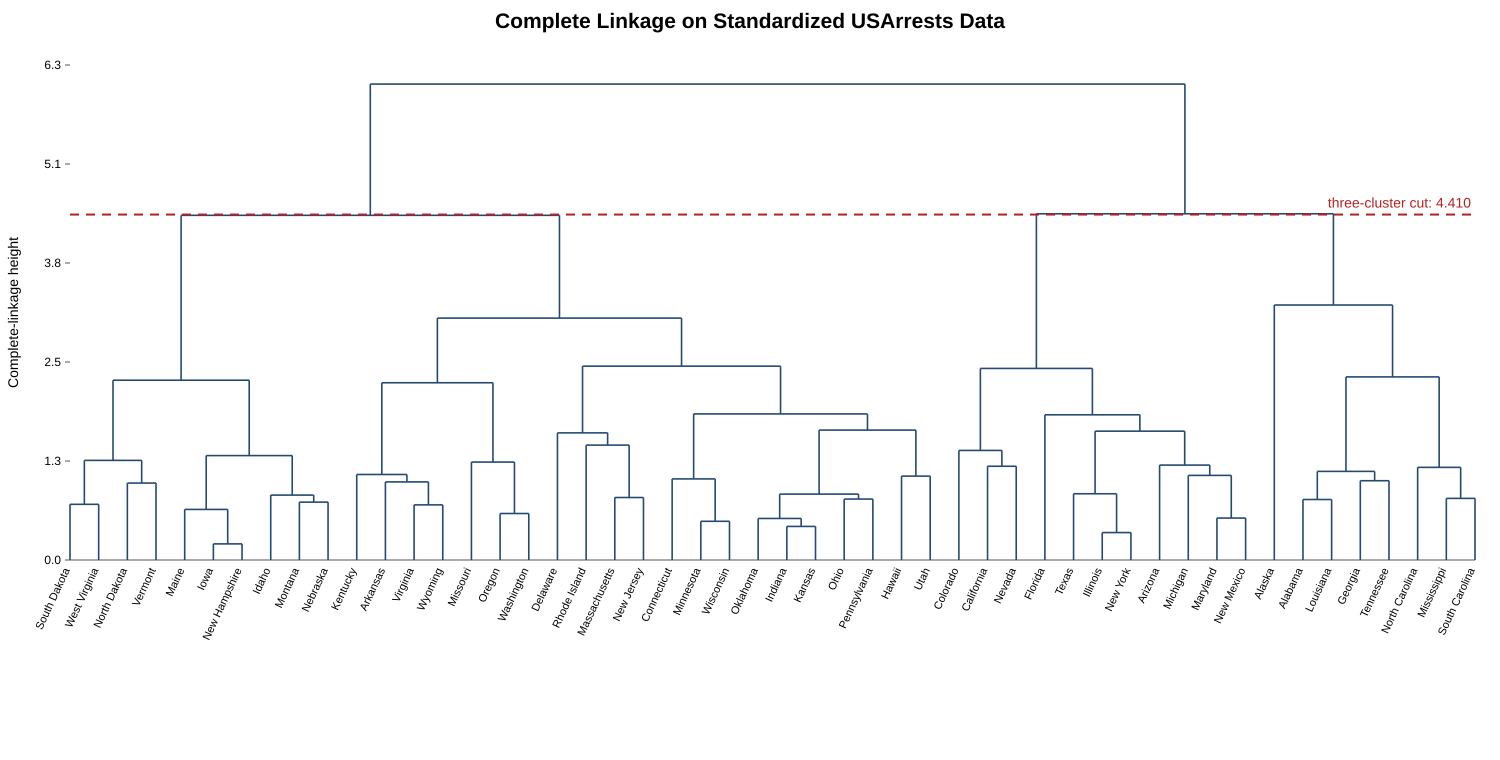

In [10]:
linkage_scaled = complete_linkage(X_scaled)
labels_scaled, groups_scaled = cut_into_k_clusters(linkage_scaled, len(states), k=3)
cut_scaled = three_cluster_cut_height(linkage_scaled, len(states))

print(f"Final merge height:          {linkage_scaled[-1, 2]:.3f}")
print(f"Chosen three-cluster height: {cut_scaled:.3f}")
print(f"Number of clusters:          {len(np.unique(labels_scaled))}")

svg_scaled = dendrogram_svg(
    linkage_scaled,
    states,
    "Complete Linkage on Standardized USArrests Data",
    cut_height=cut_scaled,
)
display_svg(svg_scaled)


### Three-cluster membership after scaling


In [11]:
print_memberships(labels_scaled, states)


Cluster 1 (n = 8):
    Alabama, Alaska, Georgia, Louisiana, Mississippi, North Carolina, South
    Carolina, Tennessee

Cluster 2 (n = 11):
    Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada,
    New Mexico, New York, Texas

Cluster 3 (n = 31):
    Arkansas, Connecticut, Delaware, Hawaii, Idaho, Indiana, Iowa, Kansas,
    Kentucky, Maine, Massachusetts, Minnesota, Missouri, Montana, Nebraska, New
    Hampshire, New Jersey, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania,
    Rhode Island, South Dakota, Utah, Vermont, Virginia, Washington, West
    Virginia, Wisconsin, Wyoming



In [12]:
print("Original-variable means within each standardized-data cluster")
print(f"{'Cluster':<10}{'n':>4}" + "".join(f"{name:>12}" for name in feature_names))
for cluster in np.unique(labels_scaled):
    mask = labels_scaled == cluster
    cluster_means = X[mask].mean(axis=0)
    print(
        f"{cluster:<10}{mask.sum():>4}" +
        "".join(f"{value:>12.2f}" for value in cluster_means)
    )


Original-variable means within each standardized-data cluster
Cluster      n      Murder     Assault    UrbanPop        Rape
1            8       14.09      252.75       53.50       24.54
2           11       11.05      264.09       79.09       32.62
3           31        5.00      116.48       63.84       16.34


## 6. Part (d): Effect of scaling

Because numerical cluster labels are arbitrary, a direct comparison of label numbers can be misleading.  The following comparison (1) cross-tabulates the two partitions, (2) aligns scaled-cluster labels to maximize overlap with the unscaled labels, and (3) computes the adjusted Rand index (ARI), which is invariant to label permutations.  An ARI of 1 indicates identical partitions; smaller values indicate less agreement.


In [13]:
def contingency_table(labels_a, labels_b):
    values_a = np.unique(labels_a)
    values_b = np.unique(labels_b)
    table = np.zeros((len(values_a), len(values_b)), dtype=int)
    for i, a in enumerate(values_a):
        for j, b in enumerate(values_b):
            table[i, j] = np.sum((labels_a == a) & (labels_b == b))
    return table


def adjusted_rand_index(labels_a, labels_b):
    table = contingency_table(labels_a, labels_b)
    choose_two = lambda values: np.sum(values * (values - 1) / 2)
    sum_cells = choose_two(table)
    sum_rows = choose_two(table.sum(axis=1))
    sum_columns = choose_two(table.sum(axis=0))
    total_pairs = len(labels_a) * (len(labels_a) - 1) / 2
    expected = sum_rows * sum_columns / total_pairs
    maximum = 0.5 * (sum_rows + sum_columns)
    return float((sum_cells - expected) / (maximum - expected))


comparison = contingency_table(labels_raw, labels_scaled)
print("Cross-tabulation: rows = unscaled clusters; columns = scaled clusters")
print("             Scaled 1  Scaled 2  Scaled 3")
for row_number, row in enumerate(comparison, start=1):
    print(f"Unscaled {row_number}:" + "".join(f"{value:>10}" for value in row))

scaled_values = np.unique(labels_scaled)
raw_values = np.unique(labels_raw)
best_mapping = None
best_matches = -1
for permutation in itertools.permutations(raw_values):
    mapping = dict(zip(scaled_values, permutation))
    aligned = np.array([mapping[value] for value in labels_scaled])
    matches = int(np.sum(aligned == labels_raw))
    if matches > best_matches:
        best_mapping, best_matches = mapping, matches

aligned_scaled = np.array([best_mapping[value] for value in labels_scaled])
changed_states = states[aligned_scaled != labels_raw]
ari = adjusted_rand_index(labels_raw, labels_scaled)

print(f"\nAdjusted Rand index: {ari:.3f}")
print(
    f"Maximum-overlap agreement: "
    f"{best_matches} of {len(states)} states"
)
print(
    f"States assigned differently after label alignment "
    f"({len(changed_states)}):"
)

changed_states_text = ", ".join(changed_states.tolist())

for line in wrap(
    changed_states_text,
    width=78,
    break_long_words=False,
    break_on_hyphens=False,
):
    print("    " + line)


Cross-tabulation: rows = unscaled clusters; columns = scaled clusters
             Scaled 1  Scaled 2  Scaled 3
Unscaled 1:         6         9         1
Unscaled 2:         2         2        10
Unscaled 3:         0         0        20

Adjusted Rand index: 0.368
Maximum-overlap agreement: 31 of 50 states
States assigned differently after label alignment (19):
    Alabama, Alaska, Arkansas, Colorado, Delaware, Louisiana, Massachusetts,
    Mississippi, Missouri, New Jersey, North Carolina, Oklahoma, Oregon, Rhode
    Island, South Carolina, Texas, Virginia, Washington, Wyoming


### Answer to part (d)

Scaling materially changes the dendrogram and the three-cluster partition.  In the original data, the sample standard deviation of `Assault` is approximately 83.34, whereas the standard deviations of `Murder`, `UrbanPop`, and `Rape` are approximately 4.36, 14.47, and 9.37.  Because Euclidean distance squares coordinate differences, the large numerical spread of `Assault` implicitly gives that variable much greater weight.  The unscaled result is therefore driven largely by assault arrest rates.

After standardization, a one-standard-deviation difference has the same numerical size for every variable.  The resulting clusters depend more evenly on the states’ profiles across murder, assault, urban population, and rape rather than mainly on the variable with the largest measurement scale.  The cross-tabulation, aligned-state comparison, ARI, changed cluster means, and different merge heights above quantify this effect.

**Recommendation.**   The variables should be scaled before the inter-observation dissimilarities are computed.  Here, the columns use different units and have substantially different variances, and the exercise supplies no substantive reason to weight `Assault` more heavily merely because its values are numerically larger.  Standardization makes equal-variance weighting explicit and is more defensible for this exploratory clustering.  This recommendation is conditional rather than universal:  if subject-matter knowledge justified unequal weights, those weights should be selected deliberately instead of arising accidentally from measurement units.


## 7. Conclusions

1.  Complete-linkage hierarchical clustering was performed with Euclidean distance on all 50 states.
2.  Cutting the unscaled dendrogram at the displayed height produces exactly three clusters; their complete memberships are printed in Section 4.
3.  Standardizing every variable to sample standard deviation one and repeating the analysis also produces three clusters, listed in Section 5.
4.  Scaling changes the state groupings because it removes the unintended dominance of `Assault`.  For this data set and objective, scaling is appropriate.


<div style="text-align:center; font-weight:bold; font-size:1.15em; margin-top:1em;">References</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2; margin-top:1em;">
James, G., Witten, D., Hastie, T., Tibshirani, R., &amp; Taylor, J. (2023). <em>An introduction to statistical learning: With applications in Python</em>. Springer. https://doi.org/10.1007/978-3-031-38747-0
</div>

<div style="margin-left:0.5in; text-indent:-0.5in; line-height:2;">
R Core Team. (n.d.). <em>USArrests: Violent crime rates by US state</em> [Data set]. R Project for Statistical Computing. https://search.r-project.org/R/refmans/datasets/html/USArrests.html
</div>
